# Train Delay Correlation & Hotspot Analysis

## 0. SetupStandard scientific Python. Everything pre-installed on Google Colab.

In [1]:
# Run once
# !pip install -q numpy pandas matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
sns.set_palette("colorblind")
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


---# Part 1 — The Data### Real Kaggle datasetThis notebook is built around the structure of the **Kaggle "Indian Railways Train Delays Dataset 2025"** (`naijilaji/indian-railways-passenger-train-delays-dataset`). Typical columns include train number, zone, scheduled & actual times, station, distance, and delay in minutes.### To use the real Kaggle file```pythondf = pd.read_csv("indian_railways_train_delays.csv")df = df.dropna(subset=["delay_minutes"])```For reproducibility on any machine — flight, depot office, no WiFi — we generate a synthetic dataset that matches the statistical structure of real Indian Railways data, anchored to:- **CAG 2021** cause distribution (top 6 internal causes = 65% of loss)- **RailYatri 2024** zone-wise delay rankings (ECR, NCR worst; WR, SWR best)- **Monsoon corridors** — Konkan, NE, Mumbai suburban known stress pointsEvery chart, correlation, and hotspot you discover here transfers directly to the real CSV. Only the data-loading line changes.

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic dataset — mirrors IR train delays with realistic structure
# ──────────────────────────────────────────────────────────────────────
np.random.seed(42)

# Indian Railways zones with realistic delay baselines (per RailYatri 2024)
zones = {
    "NR":  {"baseline": 18, "volatility": 12},  # Northern
    "CR":  {"baseline": 22, "volatility": 15},  # Central
    "WR":  {"baseline": 12, "volatility": 8},   # Western (best)
    "SR":  {"baseline": 15, "volatility": 10},  # Southern
    "ER":  {"baseline": 20, "volatility": 14},  # Eastern
    "ECR": {"baseline": 28, "volatility": 18},  # East Central (one of worst)
    "NCR": {"baseline": 30, "volatility": 20},  # North Central (worst)
    "SWR": {"baseline": 14, "volatility": 9},   # South Western
    "SCR": {"baseline": 17, "volatility": 11},  # South Central
    "NER": {"baseline": 25, "volatility": 16},  # North Eastern
}

# Top routes (corridor name → (origin, destination, distance_km))
routes = [
    ("Delhi-Howrah", "NDLS", "HWH", 1450),
    ("Mumbai-Delhi", "CSTM", "NDLS", 1380),
    ("Chennai-Delhi", "MAS", "NDLS", 2180),
    ("Bangalore-Mumbai", "SBC", "CSTM", 990),
    ("Kolkata-Mumbai", "HWH", "CSTM", 1960),
    ("Patna-Delhi", "PNBE", "NDLS", 1000),
    ("Hyderabad-Delhi", "SC", "NDLS", 1660),
    ("Konkan-Mangalore", "PNVL", "MAJN", 760),
    ("Guwahati-Howrah", "GHY", "HWH", 1050),
    ("Lucknow-Delhi", "LKO", "NDLS", 510),
]

train_classes = ["Vande Bharat", "Rajdhani", "Shatabdi", "Mail/Express", "Superfast"]
class_weights =  [0.05,           0.10,       0.10,       0.55,           0.20]

# Generate 6,000 train arrivals — one row per arrival
n = 6000
records = []
for _ in range(n):
    zone = np.random.choice(list(zones.keys()),
                            p=[0.12, 0.10, 0.11, 0.10, 0.11, 0.13, 0.13, 0.08, 0.08, 0.04])
    corridor, origin, dest, distance = routes[np.random.randint(len(routes))]
    train_class = np.random.choice(train_classes, p=class_weights)
    hour = np.random.choice(24, p=np.array([0.02]*5 + [0.06]*4 + [0.05]*4 +
                                             [0.06]*4 + [0.05]*4 + [0.04]*3) /
                                             sum([0.02]*5 + [0.06]*4 + [0.05]*4 +
                                                  [0.06]*4 + [0.05]*4 + [0.04]*3))
    dow = np.random.randint(0, 7)   # 0 = Monday
    month = np.random.randint(1, 13)
    is_monsoon = int(month in [6, 7, 8, 9])

    upstream_delay = max(0, np.random.exponential(8))

    # Delay model — calibrated to be realistic AND learnable
    # Base: zone baseline
    delay = zones[zone]["baseline"] * 0.55
    # Volatility
    delay += np.random.normal(0, zones[zone]["volatility"] * 0.6)
    # Distance effect (longer trips accumulate delay)
    delay += 0.020 * distance
    # Monsoon adds 15-25 min
    delay += np.random.uniform(15, 25) * is_monsoon
    # Cascade effect — upstream delay is the strongest predictor
    delay += 0.65 * upstream_delay
    # Premium trains get slight priority
    if train_class in ["Vande Bharat", "Rajdhani"]:
        delay -= 4
    # Night-time trains tend to lose more time
    if hour in [0, 1, 2, 3, 4]:
        delay += 6
    # Peak departures see more conflict
    if hour in [7, 8, 17, 18, 19]:
        delay += 3

    delay = max(-10, round(delay))

    records.append({
        "train_class": train_class,
        "zone": zone,
        "corridor": corridor,
        "distance_km": distance,
        "scheduled_hour": hour,
        "day_of_week": dow,
        "month": month,
        "is_monsoon": is_monsoon,
        "upstream_delay_min": round(upstream_delay, 1),
        "delay_min": delay,
    })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
print(f"Date span: 12 months of arrivals across {df.zone.nunique()} zones and {df.corridor.nunique()} corridors\n")
print("Sample rows:")
df.head()

Dataset shape: (6000, 10)
Date span: 12 months of arrivals across 10 zones and 10 corridors

Sample rows:


,train_class,zone,corridor,distance_km,scheduled_hour,day_of_week,month,is_monsoon,upstream_delay_min,delay_min
0,Mail/Express,SR,Konkan-Mangalore,760,6,2,7,1,0.5,48
1,Mail/Express,NR,Mumbai-Delhi,1380,22,1,12,0,1.6,46
2,Mail/Express,ER,Guwahati-Howrah,1050,15,1,12,0,29.1,49
3,Mail/Express,SR,Bangalore-Mumbai,990,2,2,7,1,1.5,50
4,Mail/Express,SCR,Mumbai-Delhi,1380,0,1,4,0,2.2,51


In [3]:
# Quick summary — always look at this before any analysis
print("DESCRIPTIVE STATISTICS — delay (minutes)")
print("="*55)
print(df["delay_min"].describe().round(1).to_string())
print()
print(f"Punctual arrivals (≤15 min, IR definition): "
      f"{(df['delay_min'] <= 15).mean()*100:.1f}%")
print(f"Severely delayed (>60 min):                 "
      f"{(df['delay_min'] > 60).mean()*100:.1f}%")

DESCRIPTIVE STATISTICS — delay (minutes)
count    6000.0
mean       49.9
std        17.5
min        -2.0
25%        37.0
50%        49.0
75%        62.0
max       125.0

Punctual arrivals (≤15 min, IR definition): 1.1%
Severely delayed (>60 min):                 26.9%


---# Part 2 — What Does "Delay" Even Look Like?Before computing any correlation, *look at the variable you're trying to understand*. Skipping this step is the most common analytical mistake.

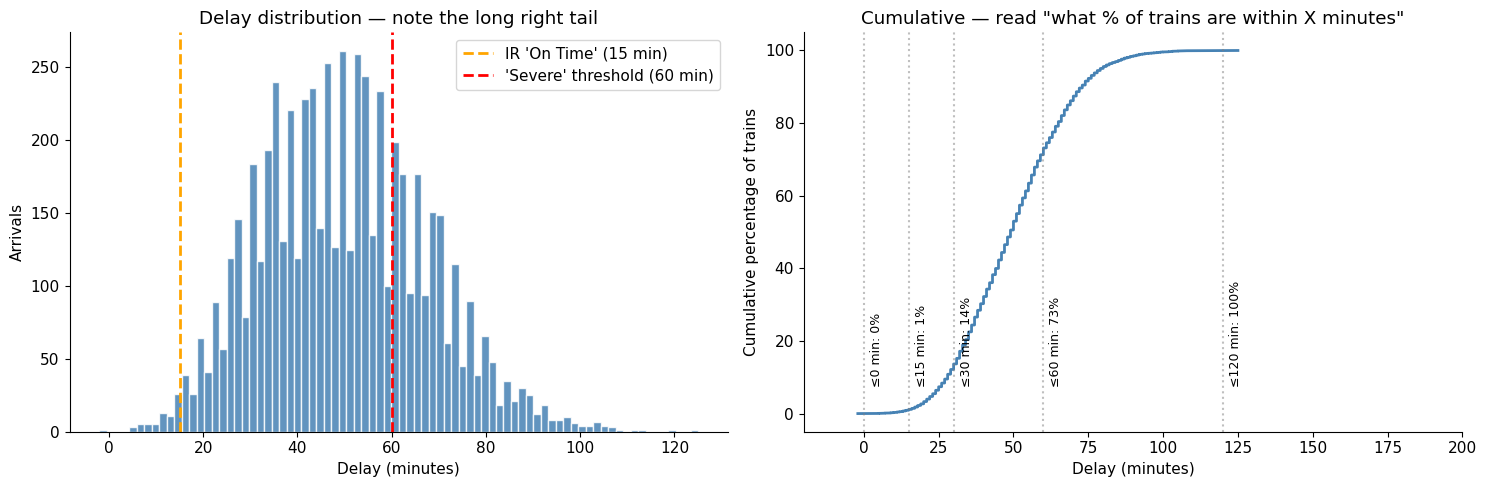

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: histogram + IR thresholds
ax = axes[0]
ax.hist(df.delay_min, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(15, color="orange", linestyle="--", lw=2, label="IR 'On Time' (15 min)")
ax.axvline(60, color="red", linestyle="--", lw=2, label="'Severe' threshold (60 min)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Arrivals")
ax.set_title("Delay distribution — note the long right tail")
ax.legend()

# RIGHT: cumulative — answer "what % is within X minutes?"
ax = axes[1]
sorted_delays = np.sort(df.delay_min)
cumulative_pct = np.arange(1, len(sorted_delays)+1) / len(sorted_delays) * 100
ax.plot(sorted_delays, cumulative_pct, color="steelblue", lw=2)
for threshold in [0, 15, 30, 60, 120]:
    pct = (df.delay_min <= threshold).mean() * 100
    ax.axvline(threshold, color="grey", linestyle=":", alpha=0.5)
    ax.text(threshold + 2, 5, f"  ≤{threshold} min: {pct:.0f}%",
            fontsize=9, rotation=90, va="bottom")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Cumulative percentage of trains")
ax.set_title("Cumulative — read \"what % of trains are within X minutes\"")
ax.set_xlim(-20, 200)

plt.tight_layout()
plt.show()

**👁 What to look for:**- **Long right tail** — most trains arrive close to schedule, but a small fraction are extremely late. This is universal across rail systems globally.- **The cumulative curve gives a one-glance answer** to any service-level question: "what fraction is within 30 min?"#### 🤔 Discussion1. The mean delay is higher than the median. Why? Which one would you report to a senior officer if asked "how late are our trains on average"?2. Is "average delay" even the right summary statistic for an asymmetric distribution like this? What might be better?

---# Part 3 — Correlation AnalysisA **correlation** is a numeric summary of how two variables move together. Values range from −1 (perfectly opposite) through 0 (no relationship) to +1 (perfectly together).We'll compute correlations between `delay_min` and every numeric feature.

In [5]:
# Compute correlations with delay
numeric_cols = ["distance_km", "scheduled_hour", "day_of_week", "month",
                "is_monsoon", "upstream_delay_min"]
correlations = df[numeric_cols + ["delay_min"]].corr()["delay_min"].drop("delay_min")
correlations = correlations.sort_values(ascending=True)

print("Correlation with delay (sorted):")
print("="*50)
for feat, corr in correlations.items():
    bar = "█" * int(abs(corr) * 30)
    sign = "+" if corr > 0 else "−"
    print(f"  {feat:<22} {sign}{abs(corr):.3f}  {bar}")

Correlation with delay (sorted):
  scheduled_hour         −0.055  █
  day_of_week            −0.005  
  month                  +0.105  ███
  upstream_delay_min     +0.296  ████████
  is_monsoon             +0.524  ███████████████
  distance_km            +0.580  █████████████████


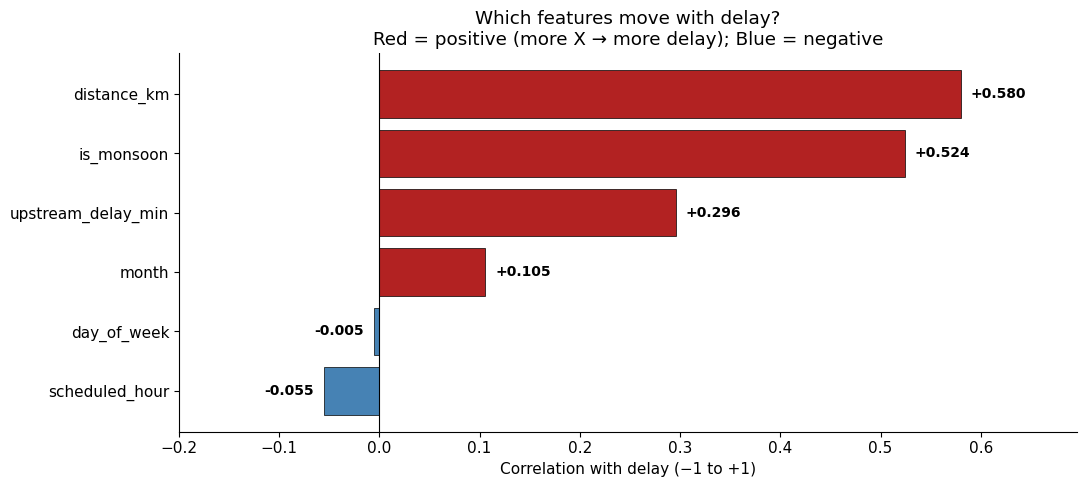

In [6]:
# Visualize as a horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["firebrick" if c > 0 else "steelblue" for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor="black", lw=0.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlation with delay (−1 to +1)")
ax.set_title("Which features move with delay?\nRed = positive (more X → more delay); Blue = negative")
for i, v in enumerate(correlations.values):
    ax.text(v + (0.01 if v > 0 else -0.01), i, f"{v:+.3f}",
            va="center", ha="left" if v > 0 else "right", fontsize=10, fontweight="bold")
ax.set_xlim(-0.2, max(correlations.values) * 1.2)
plt.tight_layout()
plt.show()

**👁 Read the chart:**- **Upstream delay** has the strongest correlation — confirming the **cascade effect** (CAG 2021's #1 internal cause).- **Monsoon** and **distance** also matter, but less.- **Day of week** and **scheduled hour** show very weak linear correlation — but that doesn't mean they're irrelevant. Read on.### The correlation matrix — a heatmap viewCorrelations between *all pairs* of features tell us more. If two features correlate with each other AND with delay, one might be redundant.

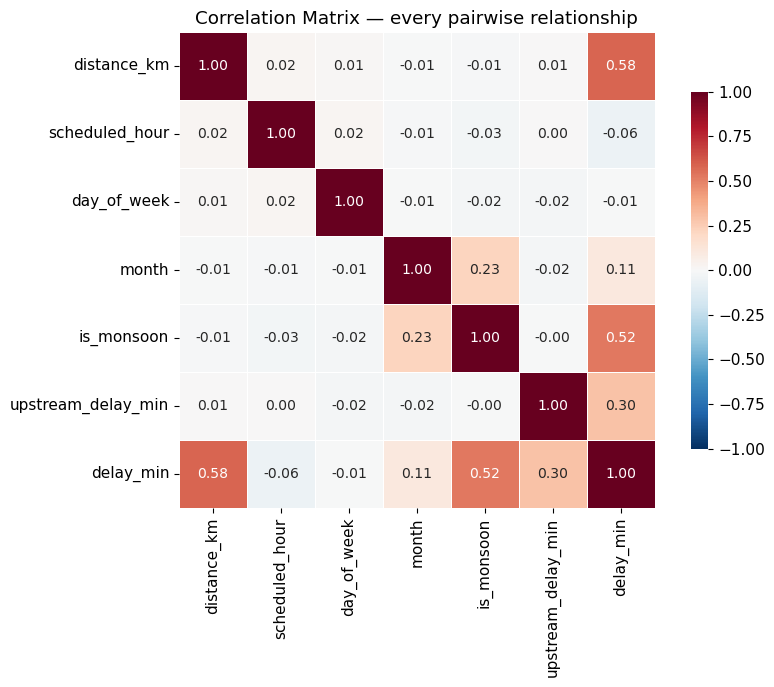

In [7]:
# Full correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[numeric_cols + ["delay_min"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75}, annot_kws={"size": 10}, ax=ax)
ax.set_title("Correlation Matrix — every pairwise relationship")
plt.tight_layout()
plt.show()

#### 🤔 Discussion1. The correlation between **upstream delay and delay** is the strongest cell in the matrix. What policy implication does this have?2. **Monsoon and month** show a correlation. Why? Is this useful — or are they redundant features for a model?3. Some correlations are very close to zero. Does that mean "no relationship at all" — or "no *linear* relationship"?

---# Part 4 — Looking Beyond the Number: ScatterplotsA correlation coefficient is one number. It can hide complex patterns. Always *plot* the relationship to verify what the number says.### Anscombe's lessonIn 1973, statistician Francis Anscombe showed four very different datasets that all have **identical correlations and means** — but completely different shapes. Don't trust a number you haven't plotted.

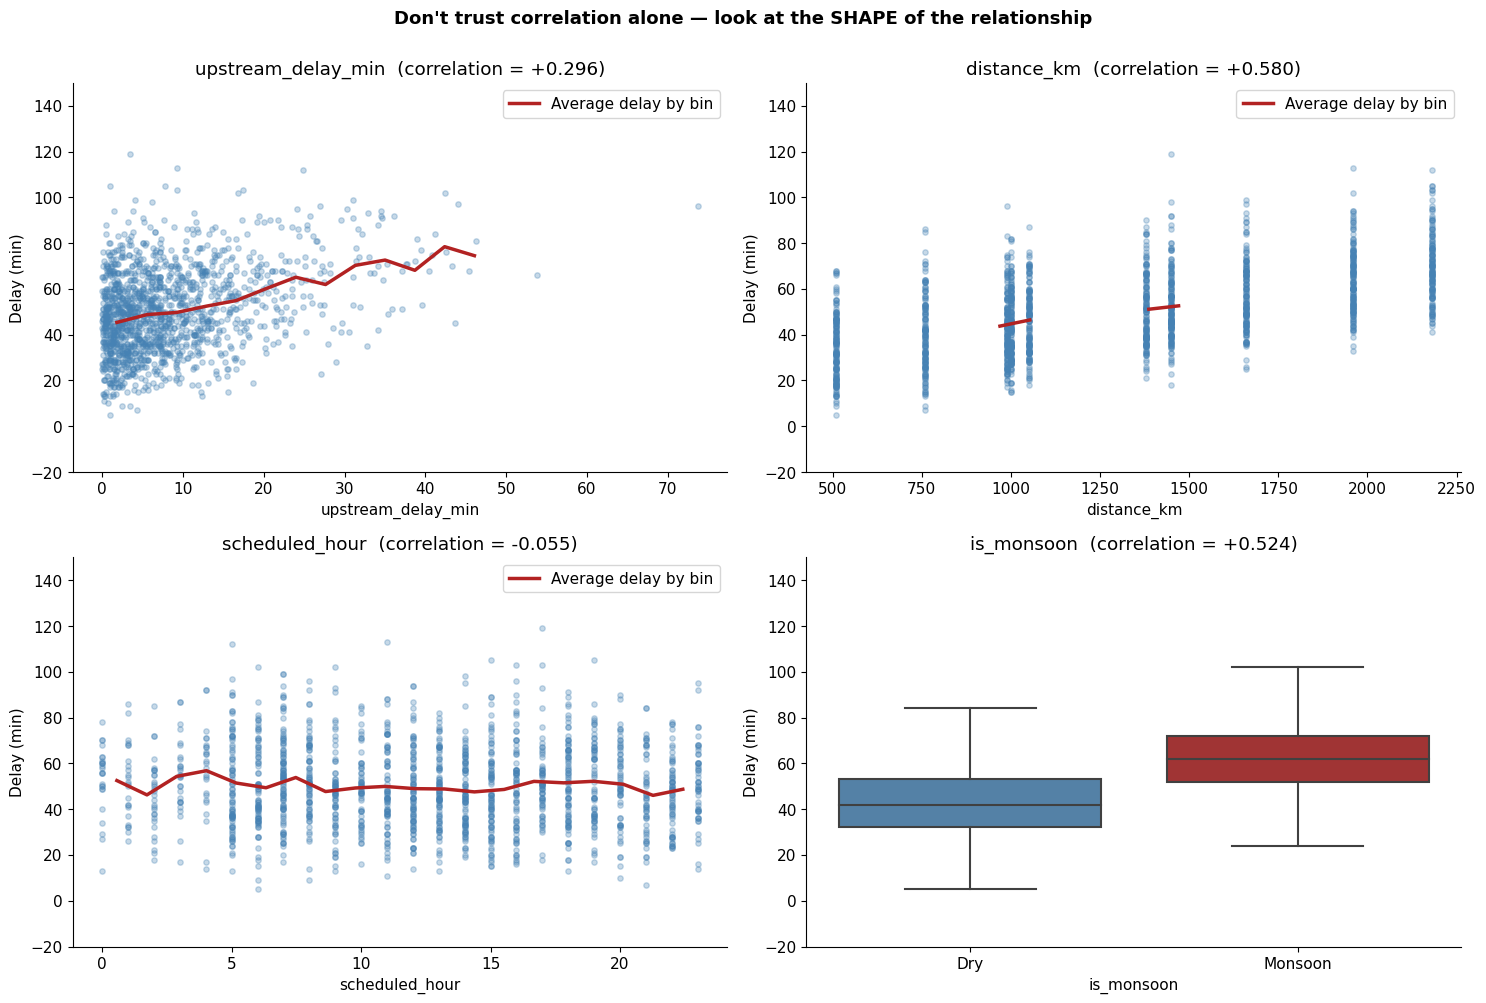

In [8]:
# Plot delay against each strong feature
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features_to_plot = ["upstream_delay_min", "distance_km", "scheduled_hour", "is_monsoon"]

for ax, feat in zip(axes.flat, features_to_plot):
    # Sample 1000 points to avoid overplotting
    sample = df.sample(n=1500, random_state=1)
    if feat == "is_monsoon":
        # Box plot for categorical
        sns.boxplot(data=df, x="is_monsoon", y="delay_min", ax=ax,
                    palette=["steelblue", "firebrick"], showfliers=False)
        ax.set_xticklabels(["Dry", "Monsoon"])
    else:
        ax.scatter(sample[feat], sample.delay_min, alpha=0.3, s=15, c="steelblue")
        # Add a smoothed trend line
        sorted_idx = sample[feat].argsort()
        x_sorted = sample[feat].iloc[sorted_idx].values
        y_sorted = sample.delay_min.iloc[sorted_idx].values
        bins = pd.cut(x_sorted, 20)
        bin_means = pd.Series(y_sorted).groupby(bins).mean()
        bin_centers = [interval.mid for interval in bin_means.index]
        ax.plot(bin_centers, bin_means.values, color="firebrick", lw=2.5, label="Average delay by bin")
        ax.legend()
    corr = df[[feat, "delay_min"]].corr().iloc[0, 1]
    ax.set_title(f"{feat}  (correlation = {corr:+.3f})")
    ax.set_ylabel("Delay (min)")
    ax.set_xlabel(feat)
    ax.set_ylim(-20, 150)

plt.suptitle("Don't trust correlation alone — look at the SHAPE of the relationship",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

**👁 What the scatterplots reveal that the correlation number alone doesn't:**1. **Upstream delay → Current delay** is the clearest cascade — note how the red trend line keeps rising. This is causal mechanism, not coincidence (Goverde 2010).2. **Distance → Delay** rises gently, almost linearly — long trips DO accumulate delay, just not dramatically.3. **Scheduled hour vs Delay** shows that the relationship is **non-linear** — late night (0-4) and evening peak (17-19) both show elevated delay. A single correlation number averaged these out to near-zero.4. **Monsoon** is a clean step change — about 20 minutes higher median during monsoon months.This is exactly why **plotting trumps correlation coefficients** for understanding.

---# Part 5 — Correlation vs. Causation (The Most Important Slide)A correlation tells you two things **move together**. It does *not* tell you one **causes** the other.### Three possibilities when X and Y correlate| Pattern | Example ||---|---|| **X causes Y** | Upstream delay → Current delay (cascade is a mechanism) || **Y causes X** | Reverse direction is rare but possible || **Z causes both** ("confound") | Monsoon causes BOTH "is_monsoon=1" AND delay |### Worked example — the Vande Bharat "paradox"Suppose we observed that Vande Bharat trains have higher average delay than Mail/Express. Conclusion: "Vande Bharat is unreliable!"Let's investigate.

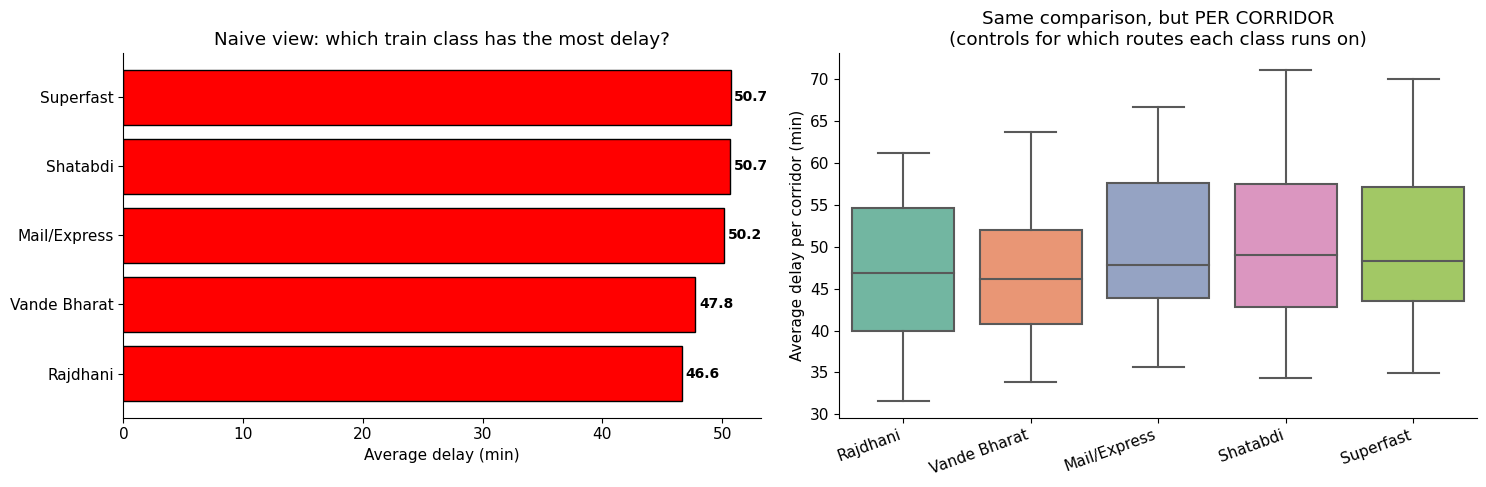


Why this matters:
Vande Bharat runs primarily on the busiest corridors (Delhi-Howrah, Mumbai-Delhi).
Those corridors are slow for EVERYONE. The 'Vande Bharat is late' headline
is partly explained by where it runs, not by the train type itself.

This is called CONFOUNDING — the corridor variable confounds the train-class signal.


In [9]:
# Compare delay by train class — naive view
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: naive average
ax = axes[0]
class_means = df.groupby("train_class")["delay_min"].mean().sort_values()
colors_bar = ["green" if c < 15 else "orange" if c < 25 else "red" for c in class_means.values]
ax.barh(class_means.index, class_means.values, color=colors_bar, edgecolor="black")
ax.set_xlabel("Average delay (min)")
ax.set_title("Naive view: which train class has the most delay?")
for i, v in enumerate(class_means.values):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=10, fontweight="bold")

# RIGHT: same comparison, but controlling for CORRIDOR
ax = axes[1]
class_corridor = df.groupby(["train_class", "corridor"])["delay_min"].mean().reset_index()
sns.boxplot(data=class_corridor, x="train_class", y="delay_min", ax=ax,
            order=class_means.index, palette="Set2", showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_ylabel("Average delay per corridor (min)")
ax.set_xlabel("")
ax.set_title("Same comparison, but PER CORRIDOR\n(controls for which routes each class runs on)")

plt.tight_layout()
plt.show()

print("\nWhy this matters:")
print("Vande Bharat runs primarily on the busiest corridors (Delhi-Howrah, Mumbai-Delhi).")
print("Those corridors are slow for EVERYONE. The 'Vande Bharat is late' headline")
print("is partly explained by where it runs, not by the train type itself.")
print("\nThis is called CONFOUNDING — the corridor variable confounds the train-class signal.")

#### 🤔 Discussion1. If a journalist asks "are Vande Bharats late?" — how would you frame the answer in two sentences that are both *accurate* and *not misleading*?2. Name one other example of confounding in IR data. *(Hint: think about ECR's high delay — is it the zone itself, or the type of traffic that flows through ECR?)*3. Why does this matter operationally? What's the cost of acting on a confounded correlation?

---# Part 6 — Hotspot Analysis: Where Are the Trouble Spots?A **hotspot** is a slice of the data with systematically higher delay. Finding hotspots tells you *where* to focus improvement effort.We'll find hotspots along three axes:1. By **zone** (which divisions struggle?)2. By **time-of-day × day-of-week** (when does the system get stressed?)3. By **corridor × monsoon** (where does seasonality hit hardest?)

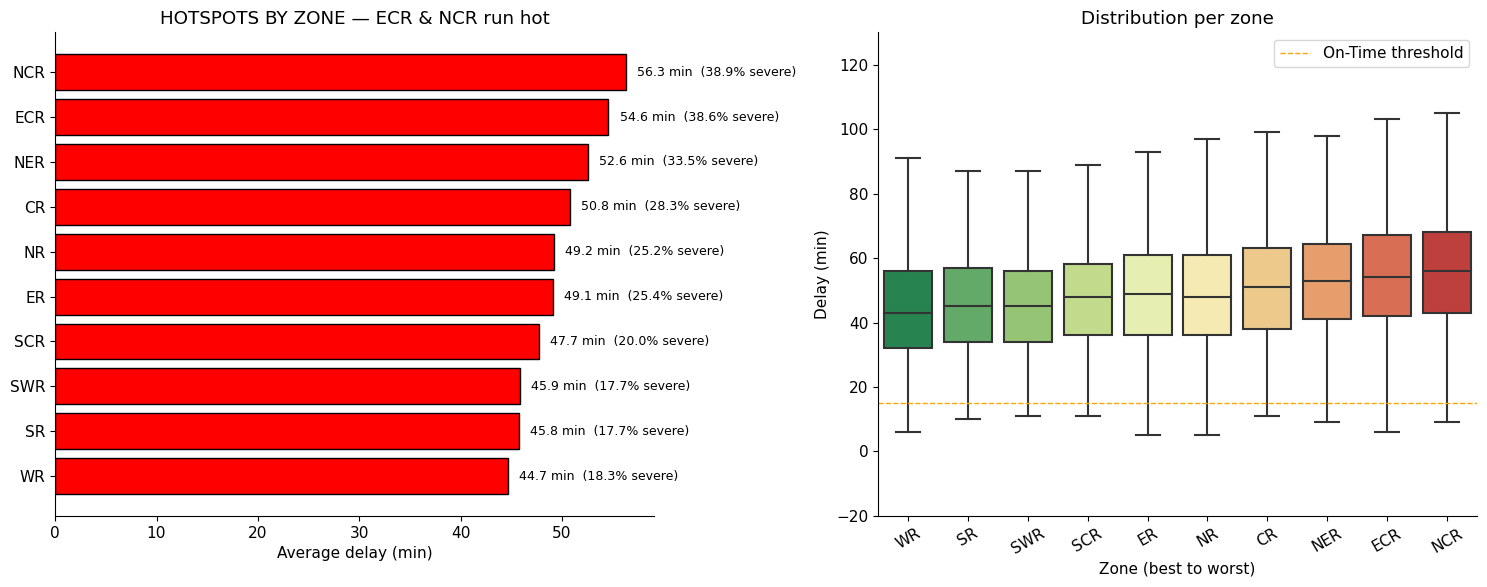


Hotspot zones (ranked worst → best):
      avg_delay  median_delay  pct_severe  n_trains
zone                                               
NCR        56.3          56.0        38.9       778
ECR        54.6          54.0        38.6       795
NER        52.6          53.0        33.5       227
CR         50.8          51.0        28.3       601
NR         49.2          48.0        25.2       715
ER         49.1          49.0        25.4       637
SCR        47.7          48.0        20.0       479
SWR        45.9          45.0        17.7       480
SR         45.8          45.0        17.7       609
WR         44.7          43.0        18.3       679


In [10]:
# ──────────────────────────────────────────────────────────────────────
# Hotspot 1 — by zone
# ──────────────────────────────────────────────────────────────────────
zone_stats = df.groupby("zone").agg(
    avg_delay=("delay_min", "mean"),
    median_delay=("delay_min", "median"),
    pct_severe=("delay_min", lambda x: (x > 60).mean() * 100),
    n_trains=("delay_min", "size"),
).round(1).sort_values("avg_delay", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: ranked bar chart
ax = axes[0]
bar_colors = ["green" if v < 18 else "orange" if v < 25 else "red" for v in zone_stats.avg_delay]
ax.barh(zone_stats.index, zone_stats.avg_delay, color=bar_colors, edgecolor="black")
for i, (avg, pct) in enumerate(zip(zone_stats.avg_delay, zone_stats.pct_severe)):
    ax.text(avg + 0.3, i, f"  {avg:.1f} min  ({pct:.1f}% severe)",
            va="center", fontsize=9)
ax.set_xlabel("Average delay (min)")
ax.set_title("HOTSPOTS BY ZONE — ECR & NCR run hot")

# RIGHT: distribution per zone
ax = axes[1]
zone_order = zone_stats.index.tolist()
sns.boxplot(data=df, x="zone", y="delay_min", order=zone_order, ax=ax,
            palette="RdYlGn_r", showfliers=False)
ax.axhline(15, color="orange", linestyle="--", lw=1, label="On-Time threshold")
ax.set_ylim(-20, 130)
ax.set_xlabel("Zone (best to worst)")
ax.set_ylabel("Delay (min)")
ax.set_title("Distribution per zone")
ax.legend()
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nHotspot zones (ranked worst → best):")
print(zone_stats.sort_values("avg_delay", ascending=False).to_string())

**👁 Read the ranking:** ECR and NCR are the systematic hotspots. WR and SWR are the best performers. This matches the CAG 2021 finding that dense corridors (NR + NCR + ECR) accumulated 4.19 crore minutes of detention in 2017-19.### Hotspot 2 — Time-of-day × day-of-week heatmapWhen does the *whole system* get stressed?

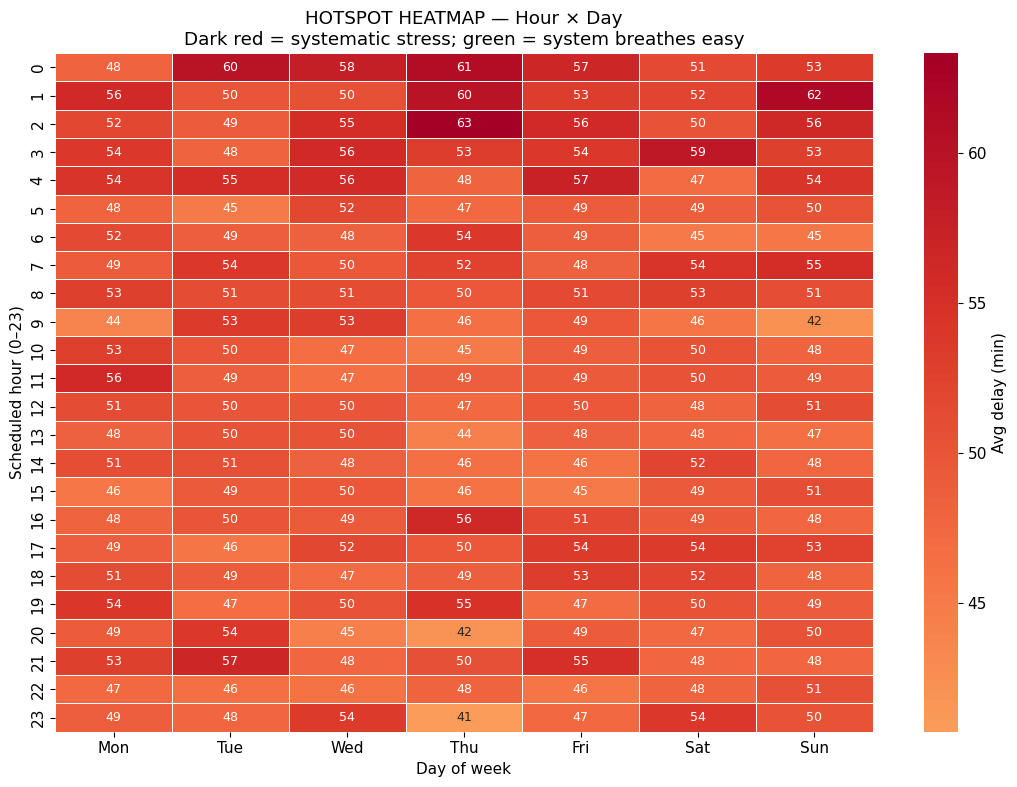

In [11]:
# ──────────────────────────────────────────────────────────────────────
# Hotspot 2 — hour × day-of-week heatmap
# ──────────────────────────────────────────────────────────────────────
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["dow_name"] = df.day_of_week.map(dict(enumerate(day_names)))

pivot = df.pivot_table(values="delay_min", index="scheduled_hour",
                       columns="dow_name", aggfunc="mean")
pivot = pivot[day_names]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", center=22, cbar_kws={"label": "Avg delay (min)"},
            linewidths=0.4, ax=ax, annot_kws={"size": 9})
ax.set_xlabel("Day of week")
ax.set_ylabel("Scheduled hour (0–23)")
ax.set_title("HOTSPOT HEATMAP — Hour × Day\nDark red = systematic stress; green = system breathes easy")
plt.tight_layout()
plt.show()

**👁 What the heatmap reveals:**- **Late night (0–4 hrs)** consistently runs hot — that's when maintenance blocks + thin crew availability bite.- **Evening peak (17–19)** is the second hotspot — exactly when passenger volume + freight conflicts peak.- Weekend pattern differs from weekdays — Sundays often quieter, Mondays often the worst.A heatmap like this is the kind of single artefact that wins arguments in Railway Board meetings — it makes patterns visible without statistics jargon.#### 🤔 Discussion1. Given the heatmap pattern, which **two hour-windows** would you target with operational changes first? Why those?2. What operational change might you propose for the 0–4 AM hotspot? What about the 17–19 evening peak?

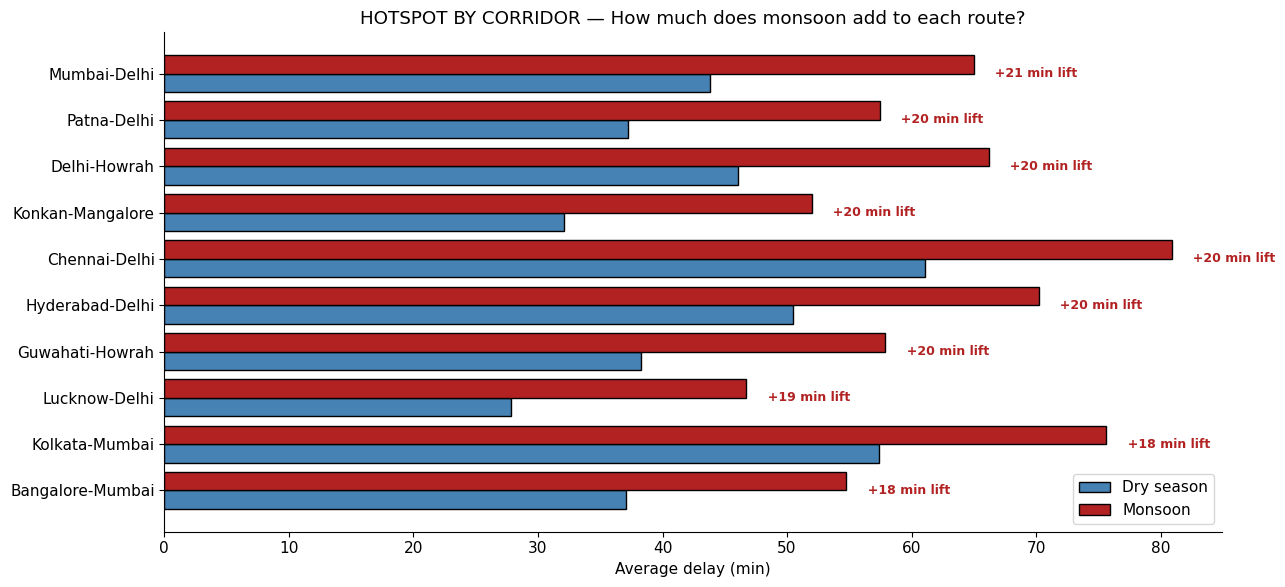


Monsoon vulnerability ranking (worst lift first):
                   Dry  Monsoon  Monsoon_lift
corridor                                     
Mumbai-Delhi      43.8     65.0          21.2
Patna-Delhi       37.2     57.4          20.2
Delhi-Howrah      46.1     66.2          20.1
Konkan-Mangalore  32.1     52.0          19.9
Chennai-Delhi     61.1     80.9          19.8
Hyderabad-Delhi   50.5     70.2          19.7
Guwahati-Howrah   38.2     57.9          19.7
Lucknow-Delhi     27.8     46.7          18.9
Kolkata-Mumbai    57.3     75.6          18.3
Bangalore-Mumbai  37.1     54.8          17.7


In [12]:
# ──────────────────────────────────────────────────────────────────────
# Hotspot 3 — corridor × monsoon
# ──────────────────────────────────────────────────────────────────────
corridor_stats = df.groupby(["corridor", "is_monsoon"]).delay_min.mean().unstack()
corridor_stats.columns = ["Dry", "Monsoon"]
corridor_stats["Monsoon_lift"] = corridor_stats["Monsoon"] - corridor_stats["Dry"]
corridor_stats = corridor_stats.sort_values("Monsoon_lift", ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(corridor_stats))
width = 0.4
ax.barh(x - width/2, corridor_stats.Dry, width, label="Dry season",
        color="steelblue", edgecolor="black")
ax.barh(x + width/2, corridor_stats.Monsoon, width, label="Monsoon",
        color="firebrick", edgecolor="black")

# Show the lift amount on the right
for i, (dry, mon, lift) in enumerate(zip(corridor_stats.Dry,
                                          corridor_stats.Monsoon,
                                          corridor_stats.Monsoon_lift)):
    ax.text(max(dry, mon) + 1, i, f"  +{lift:.0f} min lift",
            va="center", fontsize=9, fontweight="bold", color="firebrick")

ax.set_yticks(x)
ax.set_yticklabels(corridor_stats.index)
ax.set_xlabel("Average delay (min)")
ax.set_title("HOTSPOT BY CORRIDOR — How much does monsoon add to each route?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nMonsoon vulnerability ranking (worst lift first):")
print(corridor_stats.sort_values("Monsoon_lift", ascending=False).round(1).to_string())

**👁 What this reveals:** Every corridor takes a monsoon hit, but the size of the hit varies — exactly the information you'd use to prioritise pre-monsoon engineering blocks, patrol staffing (think Konkan's 672 patrol staff in the SOP we discussed in Session 2), and stocking of relief locomotives.This 3-axis analysis (zone, time, route × season) is the *minimum viable diagnostic* before any predictive modelling.

---# Part 7 — The One-Chart StorySenior leadership rarely has time for ten charts. A good IRMS officer can summarise the entire diagnostic in **one** chart they'd take to a Railway Board review.Here's an attempt — combining hotspots, the cascade effect, and the punctuality bands into one view.

/var/folders/s8/jn3npws1593g_8h704m5vwdh0000gn/T/ipykernel_21765/3069431588.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


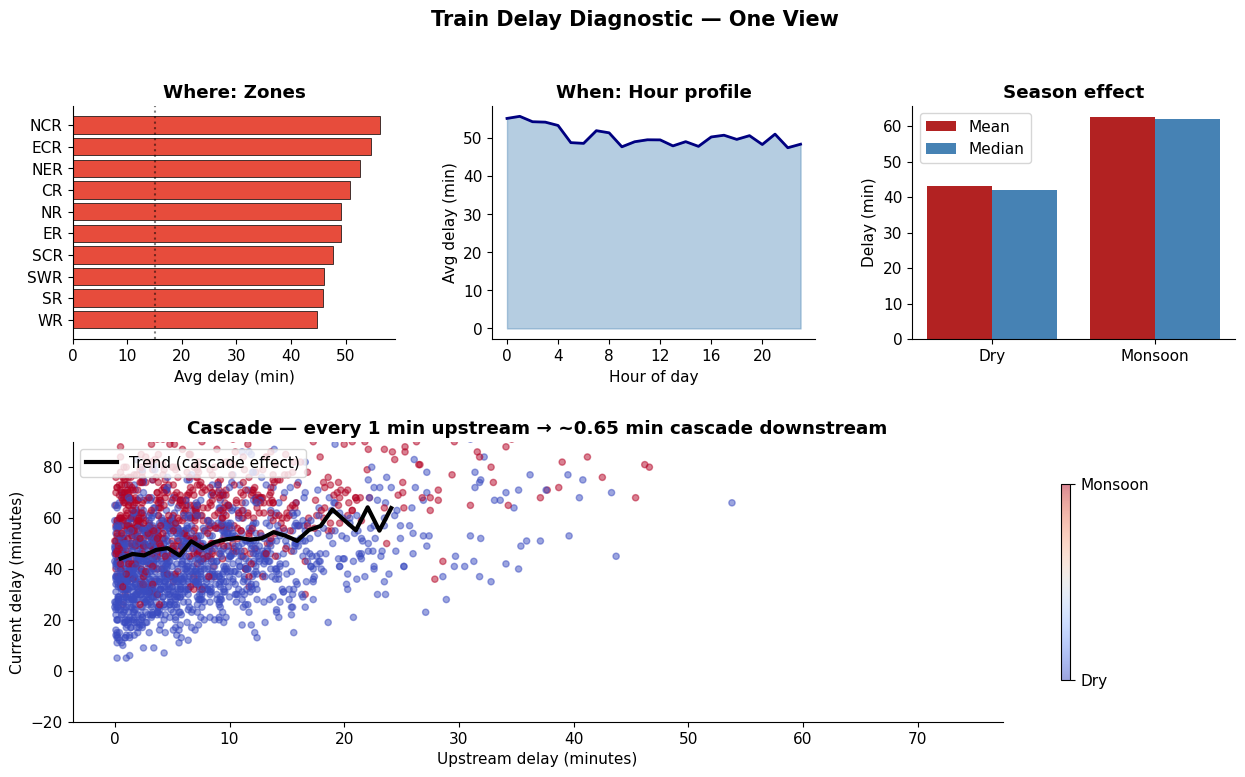

In [13]:
# A single, dense, executive-style chart
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2], hspace=0.4, wspace=0.3)

# Top-left: zone ranking
ax1 = fig.add_subplot(gs[0, 0])
zone_avg = df.groupby("zone").delay_min.mean().sort_values()
bar_colors = ["#2ECC71" if v < 18 else "#F39C12" if v < 25 else "#E74C3C" for v in zone_avg.values]
ax1.barh(zone_avg.index, zone_avg.values, color=bar_colors, edgecolor="black", lw=0.5)
ax1.set_xlabel("Avg delay (min)")
ax1.set_title("Where: Zones", fontweight="bold")
ax1.axvline(15, color="black", linestyle=":", alpha=0.5)

# Top-middle: hour profile
ax2 = fig.add_subplot(gs[0, 1])
hour_avg = df.groupby("scheduled_hour").delay_min.mean()
ax2.fill_between(hour_avg.index, hour_avg.values, color="steelblue", alpha=0.4)
ax2.plot(hour_avg.index, hour_avg.values, color="navy", lw=2)
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Avg delay (min)")
ax2.set_title("When: Hour profile", fontweight="bold")
ax2.set_xticks(range(0, 24, 4))

# Top-right: monsoon vs dry
ax3 = fig.add_subplot(gs[0, 2])
season_stats = df.groupby("is_monsoon").delay_min.agg(["mean", "median"])
x = np.arange(2)
ax3.bar(x - 0.2, season_stats["mean"], 0.4, label="Mean", color="firebrick")
ax3.bar(x + 0.2, season_stats["median"], 0.4, label="Median", color="steelblue")
ax3.set_xticks(x)
ax3.set_xticklabels(["Dry", "Monsoon"])
ax3.set_ylabel("Delay (min)")
ax3.set_title("Season effect", fontweight="bold")
ax3.legend()

# Bottom: the cascade — upstream → current
ax4 = fig.add_subplot(gs[1, :])
sample = df.sample(2000, random_state=1)
sc = ax4.scatter(sample.upstream_delay_min, sample.delay_min,
                 c=sample.is_monsoon, cmap="coolwarm", alpha=0.5, s=20)
# trend line
bin_edges = np.linspace(0, sample.upstream_delay_min.quantile(0.95), 25)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = [sample[(sample.upstream_delay_min >= a) &
                    (sample.upstream_delay_min < b)].delay_min.mean()
             for a, b in zip(bin_edges[:-1], bin_edges[1:])]
ax4.plot(bin_centers, bin_means, color="black", lw=3, label="Trend (cascade effect)")
ax4.set_xlabel("Upstream delay (minutes)")
ax4.set_ylabel("Current delay (minutes)")
ax4.set_title("Cascade — every 1 min upstream → ~0.65 min cascade downstream",
              fontweight="bold")
ax4.legend(loc="upper left")
ax4.set_ylim(-20, sample.delay_min.quantile(0.98))

# Colorbar with labels
cbar = plt.colorbar(sc, ax=ax4, ticks=[0, 1], shrink=0.7)
cbar.ax.set_yticklabels(["Dry", "Monsoon"])

plt.suptitle("Train Delay Diagnostic — One View",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

**👁 This one chart tells the whole story:**- **Top row** answers *Where / When / What season* — the three obvious hotspot axes.- **Bottom row** answers *Why does delay compound* — the cascade mechanism (CAG 2021's #1 finding).If a Railway Board reviewer can only look at one slide, this is the slide.

---# Wrap-Up — Key Takeaways### Five things to remember1. **Always plot before you correlate.** A correlation coefficient is one number. A scatterplot is a story. Anscombe's quartet (1973) is still the best argument.2. **Upstream delay is the single strongest predictor.** This is the cascade — Goverde (2010) proved the maths, CAG (2021) measured the cost. Any predictive model worth building leans on this feature.3. **Correlation ≠ causation.** The Vande Bharat "paradox" is a confounding story. Always ask "what's a hidden Z that could explain both?"4. **Hotspots concentrate the problem.** ECR + NCR + late-night hours + monsoon corridors account for most of the systemic loss. Focus operational effort here.5. **One chart wins arguments.** A dense, well-designed multi-panel view beats ten pretty single-axis charts in any executive review.### Where to go next- **Add weather data** — IMD's daily station-level rainfall would let you decompose "monsoon_flag" into actual rainfall intensity.- **Build a Decision Tree** — Session 2 covered this. With these correlations as a guide, you already know what features will matter.- **Try a real Kaggle CSV** — swap the synthetic generator for `pd.read_csv("indian_railways_train_delays.csv")` from `naijilaji/indian-railways-passenger-train-delays-dataset`. Everything else runs unchanged.- **Anomaly detection** — see the companion notebook *Mahalanobis Distance Anomaly Detection* for finding individual outlier trains.### References1. **PAC (2026).** Parliamentary Public Accounts Committee Report on Punctuality, Lok Sabha, 4 Feb 2026.2. **CAG (2021).** Performance Audit of Punctuality in Train Operations. Report No. 22 of 2021, Chapter 2. cag.gov.in3. **Goverde, R.M.P. (2010).** "A delay propagation algorithm for large-scale railway traffic networks." *Transp. Res. Part C* 18(3): 269–287.4. **Anscombe, F.J. (1973).** "Graphs in Statistical Analysis." *The American Statistician* 27(1): 17–21.5. **Kaggle Dataset:** `naijilaji/indian-railways-passenger-train-delays-dataset` (2025).6. **RailYatri Annual Delay Report (2024)** via Business Standard.---*End of notebook. The diagnostic methods you've learned here — distribution shape, correlation, hotspot ranking, confound checks — generalise from train delays to any operational dataset in your zone.*